# **18 · 측정 신뢰도·상관구조 — 배터리가 '한 요인'을 잴 자격, 데이터 쪽 토대**

### **"credibility 핵심3(공정·전문·정확)은 pooled α=0.805 · 연도별 α 0.70~0.82 · 지표 간 상관 0.55~0.64의 응집 블록이고, press_free(언론자유)는 이 블록 밖이다 — MGCFA(21)에 들어가기 전에 데이터가 먼저 말하는 단일차원성의 증거"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = cred 배터리 6종 상관구조·내적일관성(연도별 전수) · 방법 = **pooled/연도별 α + 상관 블록 구조 + 배제 근거 재검증**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **④ 피처 엔지니어링(측정 토대)** · CRISP-DM **P3·P4** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 핵심3의 내적일관성은 **모든 연도에서** 관례 기준(α ≥ 0.70)을 넘는가 — pooled 값이 특정 연도의 착시는 아닌가?
> **Q2.** 상관 행렬의 블록 구조는 핵심3 채택·나머지 배제(`02` DB①)를 데이터로 지지하는가?
> **Q3.** α가 확보하는 것과 확보하지 못하는 것은 무엇인가 — 왜 α만으로 멈추지 않고 `21`(MGCFA)로 가는가?

## **이 노트북의 위상**

`02` §2가 A트랙(지수 설계) 관점에서 α와 상관을 *한 번* 보였고 `22` §5가 semopy 교차검증의 *독립 보강*으로 α를 곁들였다면, 18은 B트랙 측정 체인(21→22→23)의 **데이터 쪽 토대**를 전수로 깐다: 연도별 α 7개, 연도별 상관 구조, 배제 지표까지 포함한 블록 대비. 계산은 전부 [`src/news_health_features.py`](../src/news_health_features.py)의 `cronbach_alpha`(자체구현·`22`에서 pingouin과 대조됨)를 재사용한다.

- **로직 SSOT(thin import)**: `nf.cronbach_alpha` · `hz.CRED_BATTERY`·`CRED_FACTOR_CORE3`.
- **관련**: `02` §2(채택 논거) · `21`(측정동등 — α의 다음 단계) · `22` §5(pingouin 대조).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] α의 역할과 한계 — **Decision Box ①** | — |
| 2 | [실행] 연도별 α 전수(핵심3 · +trustworthy 4지표) + [시각화] | α 표·figure |
| 3 | [발견] 상관 블록 구조 — 채택과 배제의 데이터 근거 + [시각화] | 히트맵 |
| 4 | [입증] 검증 셀 — 문서 수치 대조 assert | PASS |
| 5 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz
import news_health_features as nf

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
CORE3 = hz.CRED_FACTOR_CORE3
BATTERY = list(hz.CRED_BATTERY)          # 6종(core3 + trustworthy + press_free + influence)
kr = {"cred_fair": "공정", "cred_professional": "전문", "cred_accurate": "정확",
      "cred_trustworthy": "신뢰", "press_free": "자유", "media_influence": "영향력"}
print(f"패널 {len(panel):,}행 · 배터리 {len(BATTERY)}종 · 핵심3 = {[kr[c] for c in CORE3]}")

패널 90,996행 · 배터리 6종 · 핵심3 = ['공정', '전문', '정확']


## **1. [전제] α는 무엇을 보증하고 무엇을 못 하는가**

### **Decision Box ① — 내적일관성 판정: α의 위치**

**기준: 단일차원성 주장에서 α에게 어떤 역할을 맡기는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) α ≥ 0.7이면 단일차원 확정 | α 하나로 측정 자격 종결 | ❌ α는 지표 간 공분산의 요약일 뿐 — **차원 수를 검정하지 않고**(2요인이어도 α는 높을 수 있음), 연도 간 동등성은 아예 다루지 못함 |
| (b) α 생략, CFA만 | 바로 MGCFA로 | ❌ 가능하지만, 모형 없이 데이터가 먼저 보여주는 응집(상관 블록·α)을 건너뛰면 "모형이 만들어낸 요인" 의심에 선제 대응 못 함 |
| (c) **α·상관 = 토대, CFA = 판정** | α(관례 0.70)와 상관 블록으로 응집을 확인하고, 차원·동등성 판정은 `21`~`23`에 위임 | ✅ **채택** — 역할 분담: 이 노트북은 "요인분석에 넣을 자격", `21`은 "연도 비교 자격" |

**'관례 0.70'의 서지 노트**: 이 임계의 통상 출처인 Nunnally (1978, *Psychometric Theory* 2nd ed.)에서 .70은 **초기 연구 단계**의 권고이며(기초연구 .80, 적용·의사결정 목적 검사 .90+ — Nunnally & Bernstein 1994에서도 유지), 보편적 '합격선'이 아니다. 절단값이 원 맥락을 벗어나 반복 인용되는 관행에 대한 비판은 Lance, Butts & Michels (2006, *ORM* 9(2), DOI 10.1177/1094428105284919). 그래서 본 파이프라인은 (a)를 기각하고 0.70을 "요인분석 투입 자격의 관례적 하한" 이상으로 쓰지 않는다 — 대안 (c)의 역할 분담이 이 비판과 정합한다. 상세: `docs/groundwork/10-research-notebook-citation-gaps.md` §4-②.

**연도별 전수의 이유**: pooled α=0.805는 90,996행의 평균적 요약이다. 특정 연도에서 배터리가 무너졌다면(예: 한 해만 α 0.5) pooled는 그것을 가릴 수 있다 — 연도별 7개 값 전수가 시계열 분석의 실질 토대다.

## **2. [실행] 연도별 α 전수**

**[시각화] α 사다리** — 핵심3(7개년)과 4지표(+trustworthy, 2019~2022)의 연도별 α. 관례 기준 0.70 수평선 위에 전 연도가 있는지가 판정.

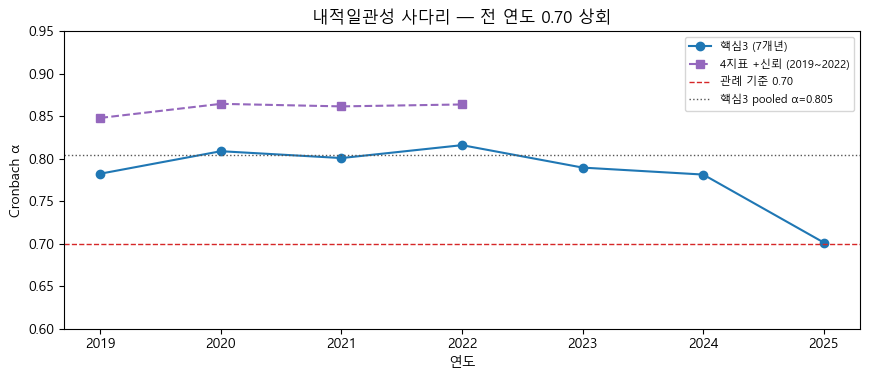

pooled α(핵심3) = 0.805


,핵심3 α,4지표 α
2019,0.782,0.848
2020,0.809,0.865
2021,0.801,0.862
2022,0.816,0.864
2023,0.790,NaN
2024,0.781,NaN
2025,0.701,NaN


In [2]:
def alpha_by_year(items, years):
    out = {}
    for y in years:
        X = panel.loc[panel["year"] == y, items].apply(pd.to_numeric, errors="coerce").dropna()
        out[y] = nf.cronbach_alpha(X)
    return out

a3 = alpha_by_year(CORE3, hz.YEARS)
a4 = alpha_by_year(hz.CRED_FACTOR_PLUS4, [2019, 2020, 2021, 2022])
X_pool = panel[CORE3].apply(pd.to_numeric, errors="coerce").dropna()
a_pool = nf.cronbach_alpha(X_pool)

fig, ax = plt.subplots(figsize=(8.8, 3.9))
ax.plot(list(a3), list(a3.values()), "o-", color="#1f77b4", label="핵심3 (7개년)")
ax.plot(list(a4), list(a4.values()), "s--", color="#9467bd", label="4지표 +신뢰 (2019~2022)")
ax.axhline(0.70, ls="--", color="#d62728", lw=1, label="관례 기준 0.70")
ax.axhline(a_pool, ls=":", color="#555", lw=1, label=f"핵심3 pooled α={a_pool:.3f}")
ax.set_ylim(0.6, 0.95); ax.set_xlabel("연도"); ax.set_ylabel("Cronbach α")
ax.set_title("내적일관성 사다리 — 전 연도 0.70 상회")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

tbl = pd.DataFrame({"핵심3 α": pd.Series(a3).round(3), "4지표 α": pd.Series(a4).round(3)})
print(f"pooled α(핵심3) = {a_pool:.3f}")
tbl

**관찰**: 핵심3 α는 전 연도 0.70 상회(범위 0.70~0.82), pooled 0.805. trustworthy를 더한 4지표는 α가 더 높다(지표 수 효과 + 응집) — 그러나 2023년부터 문항이 사라져 종단 주모형이 될 수 없다(`02` [발견 ①]). "가장 신뢰도 높은 조합"이 아니라 "**7개년 내내 존재하는 응집 조합**"이 종단의 제약이라는 것이 핵심3 채택의 본질이다.

## **3. [발견] 상관 블록 구조 — 채택·배제의 데이터 근거**

**[시각화] pooled 상관 히트맵(6종 전체)** — 핵심3 블록(좌상단)이 서로 진하고, `press_free`(자유)·`media_influence`(영향력)는 블록 밖에서 옅다. 채택/배제(`02` DB①)가 개념 논거만이 아니라 상관 구조에서도 재확인된다.

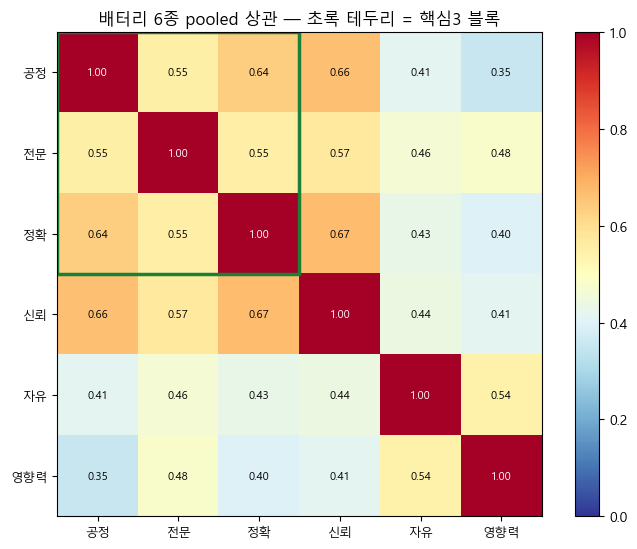

핵심3 쌍 상관: [0.55, 0.64, 0.55] · press_free↔핵심3: [0.41, 0.46, 0.43]


In [3]:
sub = panel[BATTERY].apply(pd.to_numeric, errors="coerce")
corr = sub.corr(method="pearson", min_periods=1000)

fig, ax = plt.subplots(figsize=(7.2, 5.6))
im = ax.imshow(corr.values, cmap="RdYlBu_r", vmin=0, vmax=1)
labels = [kr[c] for c in BATTERY]
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if v > 0.75 else "black")
import matplotlib.patches as mpatches
ax.add_patch(mpatches.Rectangle((-0.5, -0.5), 3, 3, fill=False, ec="#1a7f37", lw=2.5))
ax.set_title("배터리 6종 pooled 상관 — 초록 테두리 = 핵심3 블록")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout(); plt.show()

core_pairs = [corr.loc[a, b] for i, a in enumerate(CORE3) for b in CORE3[i+1:]]
out_free = [corr.loc["press_free", c] for c in CORE3]
print(f"핵심3 쌍 상관: {[round(float(v),2) for v in core_pairs]} · press_free↔핵심3: {[round(float(v),2) for v in out_free]}")

**관찰**: 핵심3 쌍 상관(0.55~0.64)이 press_free↔핵심3보다 일관되게 높다 — '언론활동이 자유롭다'는 평가 대상(제도 환경)이 달라 같은 요인의 지표가 아니라는 `02`의 개념 판단이 수치로 뒷받침된다. `media_influence`는 valence(영향력이 크다=좋다?)가 불일치해 애초에 다른 성질의 문항이다.

## **4. [입증] 검증 셀 — 문서 수치 대조**

In [4]:
# (a) pooled α — 문서 값 0.805 (02 §2·README)
assert abs(a_pool - 0.805) <= 0.01, f"pooled α {a_pool:.3f} vs 문서 0.805"
print(f"(a) pooled α(핵심3) = {a_pool:.3f} ↔ 문서 0.805 (±0.01) PASS")

# (b) 연도별 α — 문서 범위 0.70~0.82, 전 연도 ≥ 0.70
vals = np.array(list(a3.values()))
assert (vals >= 0.695).all(), f"연도별 α 최소 {vals.min():.3f}"
assert 0.69 <= vals.min() <= 0.72 and 0.80 <= vals.max() <= 0.84
print(f"(b) 연도별 α 범위 {vals.min():.3f}~{vals.max():.3f} ↔ 문서 0.70~0.82 PASS")

# (c) 핵심3 쌍 상관 — 문서 범위 0.55~0.64
cp = np.array([float(v) for v in core_pairs])
assert (cp >= 0.53).all() and (cp <= 0.66).all(), cp
print(f"(c) 핵심3 쌍 상관 {np.round(cp, 3).tolist()} ↔ 문서 0.55~0.64 PASS")

# (d) 블록 구조 — 핵심3 쌍 최솟값 > press_free↔핵심3 최댓값
assert cp.min() > max(float(v) for v in out_free)
print("(d) 블록 분리: min(핵심3 쌍) > max(press_free↔핵심3) PASS")
print("\n검증 (a)~(d) 전부 PASS")

(a) pooled α(핵심3) = 0.805 ↔ 문서 0.805 (±0.01) PASS
(b) 연도별 α 범위 0.701~0.816 ↔ 문서 0.70~0.82 PASS
(c) 핵심3 쌍 상관 [0.55, 0.636, 0.553] ↔ 문서 0.55~0.64 PASS
(d) 블록 분리: min(핵심3 쌍) > max(press_free↔핵심3) PASS

검증 (a)~(d) 전부 PASS


## **5. 종합**

### **연구질문 답**

- **Q1** — 그렇다. 연도별 α 7개 전부 0.70 상회(0.70~0.82), pooled 0.805 — 특정 연도 붕괴 없음(§2). 시계열 분석의 데이터 토대가 전 구간에서 성립한다.
- **Q2** — 그렇다. 핵심3 블록(0.55~0.64)이 press_free와의 상관을 전 쌍에서 상회(§3·§4 (d)) — 채택·배제가 개념과 데이터 양쪽에서 지지된다.
- **Q3** — α는 "요인분석에 넣을 자격"까지만 보증한다(DB①). 차원 수·연도 간 동등성(같은 잣대인가)은 `21`(MGCFA)·`22`(교차검증)·`23`(정렬법)의 일이다 — 이 노트북은 그 체인의 첫 디딤돌이다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 연도별 α 전수(핵심3·4지표) + pooled | 전 연도 ≥0.70 |
| 3 | 상관 블록 구조 히트맵 | 채택·배제 지지 |
| 4 | 문서 수치 대조 assert | **PASS** |

**다음**: `19`(품질 게이트 종합)로 1x 데이터 트랙을 닫고, 측정 체인은 `21`로 이어진다.